# Neural Network using pytorch

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt

Load data

In [ ]:
data = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

In [ ]:
print('Info about the dataset')

# data.head()
data.info()

Info about the dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
data.shape

(891, 12)

# Preprocessing

* Drop unnecessary features

In [ ]:
## Dropping unnecessary columns
data = data.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])



* Handle missing values

In [ ]:
missing_values = data.isnull().sum()
print(missing_values)

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64


* There is 177 missing values in age
- so we need to do somthing about it
- Here we will fill missing values with the midain

In [ ]:
data["Age"].fillna(data["Age"].median(), inplace=True)
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

missing_values = data.isnull().sum()
print(missing_values)


Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


/tmp/ipython-input-4171484301.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Age"].fillna(data["Age"].median(), inplace=True)
/tmp/ipython-input-4171484301.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

## Encoding categorical feature

In [ ]:
le = LabelEncoder()
data['Sex'] = le.fit_transform(data['Sex'])
data['Embarked'] = le.fit_transform(data['Embarked'])

#-----------------------------

# data["Sex"].head()
data["Embarked"].head()
#


,Embarked
0,2
1,0
2,2
3,2
4,2


## Splitting features and target

In [ ]:
X = data.drop("Survived", axis=1)
y = data["Survived"]

# X.head()
y.head()

,Survived
0,0
1,1
2,1
3,1
4,0


# scaling

- Now we need to scale all the  features , becoz sometimes modle may consider high value more important , Here for example age is 0 - 85 , but fare 0 - 500

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)




# Split data into train and test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#


X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)



y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# Model

- Here we will define three models

In [ ]:
class TitanicModel(nn.Module):

  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(X_train.shape[1] , 16)  # (Input , output)
    self.layer_2 = nn.Linear(16, 8)
    self.output_layer = nn.Linear(8, 1) # Changed to 1 output unit
    self.relu = nn.ReLU()



  def forward(self, x):
    x = torch.relu(self.layer_1(x))   # layer_1: z1 = W1 x + b1  ثم a1 = ReLU(z1)
    x = torch.relu(self.layer_2(x))   # layer_2: z2 = W2 a1 + b2 ثم a2 = ReLU(z2)
    x = torch.sigmoid(self.output_layer(x)) # output: z3 = W3 a2 + b3 ثم sigmoid(z3)

    return x





class TitanicModelVariant1(nn.Module):
    def __init__(self):
        super(TitanicModelVariant1, self).__init__()
        # الطبقة الأولى: من عدد الخصائص إلى 32 عُقدة
        self.layer_1 = nn.Linear(X_train.shape[1], 32)
        # الطبقة الثانية: من 32 إلى 16
        self.layer_2 = nn.Linear(32, 16)
        # الطبقة الثالثة: من 16 إلى 8
        self.layer_3 = nn.Linear(16, 8)
        # الطبقة الأخيرة: من 8 إلى 1 (ناتج واحد = احتمال النجاة)
        self.output = nn.Linear(8, 1)
        # دالة التنشيط المستخدمة
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.layer_1(x))   # الطبقة الأولى + ReLU
        x = self.relu(self.layer_2(x))   # الطبقة الثانية + ReLU
        x = self.relu(self.layer_3(x))   # الطبقة الثالثة + ReLU
        x = self.sigmoid(self.output(x)) # طبقة الإخراج + Sigmoid
        return x








class TitanicModelVariant2(nn.Module):
    def __init__(self):
        super(TitanicModelVariant2, self).__init__()
        self.layer_1 = nn.Linear(X_train.shape[1], 64)
        self.layer_2 = nn.Linear(64, 32)
        self.layer_3 = nn.Linear(32, 16)
        self.layer_4 = nn.Linear(16, 8)
        self.output = nn.Linear(8, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.layer_1(x))
        x = self.relu(self.layer_2(x))
        x = self.relu(self.layer_3(x))
        x = self.relu(self.layer_4(x))
        x = self.sigmoid(self.output(x))
        return x

# Initialize Models, Loss Function, and Optimizer

In [ ]:
model = TitanicModel()            # نموذج بسيط (طبقتين)
model_variant1 = TitanicModelVariant1()  # نموذج أعمق (3 طبقات)
model_variant2 = TitanicModelVariant2()  # نموذج أعمق (4 طبقات)




criterion = nn.BCELoss()  #Loss function to estimate the error

## Optimizer
# Gradinet to update W and B
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
optimizer_variant1 = torch.optim.Adam(model_variant1.parameters(), lr=0.001)
optimizer_variant2 = torch.optim.Adam(model_variant2.parameters(), lr=0.001)

# Train Models

In [ ]:
# Define number of epochs
epochs = 100

def train_model(model, optimizer, epochs):
    # Metrics Initialization
    losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []

    for epoch in range(epochs):
        # --- Train the Model ---
        model.train()  # training mode
        y_pred_train = model(X_train_tensor) # pass x to medle
        train_loss = criterion(y_pred_train, y_train_tensor.unsqueeze(1).float()) # Calculate the loss

        # Backward pass and optimization
        optimizer.zero_grad()   # Clears old gradients
        train_loss.backward()   # Computes gradients
        optimizer.step()        # Updates model parameters

        # Save training loss
        losses.append(train_loss.item())

        # --- Evaluate on test data ---
        model.eval()  # evaluation mode
        with torch.no_grad():  # disables gradient calculation
            y_pred_test = model(X_test_tensor)
            # Reshape y_test_tensor to match y_pred_test
            test_loss = criterion(y_pred_test, y_test_tensor.unsqueeze(1).float()).item()
            test_losses.append(test_loss)

            # Calculate accuracies
            y_pred_train_binary = (y_pred_train > 0.5).float()
            train_accuracy = (y_pred_train_binary.eq(y_train_tensor.unsqueeze(1).float()).sum() / y_train_tensor.shape[0]).item()
            train_accuracies.append(train_accuracy * 100)

            y_pred_test_binary = (y_pred_test > 0.5).float()
            test_accuracy = (y_pred_test_binary.eq(y_test_tensor.unsqueeze(1).float()).sum() / y_test_tensor.shape[0]).item()
            test_accuracies.append(test_accuracy * 100)


        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss:.4f}, "
                  f"Train Accuracy: {train_accuracy * 100:.2f}%, Test Accuracy: {test_accuracy * 100:.2f}%")

    return losses, test_losses, train_accuracies, test_accuracies

Now we will train the models

In [ ]:
print("Training Default Model")
losses, test_losses, train_accuracies, test_accuracies = train_model(model, optimizer, epochs)

print("\nTraining Variant 1 Model")
losses_variant1, test_losses_variant1, train_accuracies_variant1, test_accuracies_variant1 = train_model(model_variant1, optimizer_variant1, epochs)

print("\nTraining Variant 2 Model")
losses_variant2, test_losses_variant2, train_accuracies_variant2, test_accuracies_variant2 = train_model(model_variant2, optimizer_variant2, epochs)

Training Default Model
Epoch 10/100, Train Loss: 0.7083, Test Loss: 0.7018, Train Accuracy: 37.64%, Test Accuracy: 41.34%
Epoch 20/100, Train Loss: 0.7000, Test Loss: 0.6946, Train Accuracy: 37.64%, Test Accuracy: 41.34%
Epoch 30/100, Train Loss: 0.6917, Test Loss: 0.6872, Train Accuracy: 37.64%, Test Accuracy: 41.34%
Epoch 40/100, Train Loss: 0.6825, Test Loss: 0.6789, Train Accuracy: 40.73%, Test Accuracy: 44.69%
Epoch 50/100, Train Loss: 0.6722, Test Loss: 0.6695, Train Accuracy: 51.97%, Test Accuracy: 61.45%
Epoch 60/100, Train Loss: 0.6604, Test Loss: 0.6583, Train Accuracy: 73.17%, Test Accuracy: 71.51%
Epoch 70/100, Train Loss: 0.6467, Test Loss: 0.6445, Train Accuracy: 75.14%, Test Accuracy: 74.86%
Epoch 80/100, Train Loss: 0.6319, Test Loss: 0.6292, Train Accuracy: 77.53%, Test Accuracy: 76.54%
Epoch 90/100, Train Loss: 0.6164, Test Loss: 0.6134, Train Accuracy: 78.23%, Test Accuracy: 77.09%
Epoch 100/100, Train Loss: 0.6007, Test Loss: 0.5977, Train Accuracy: 78.37%, Test Acc

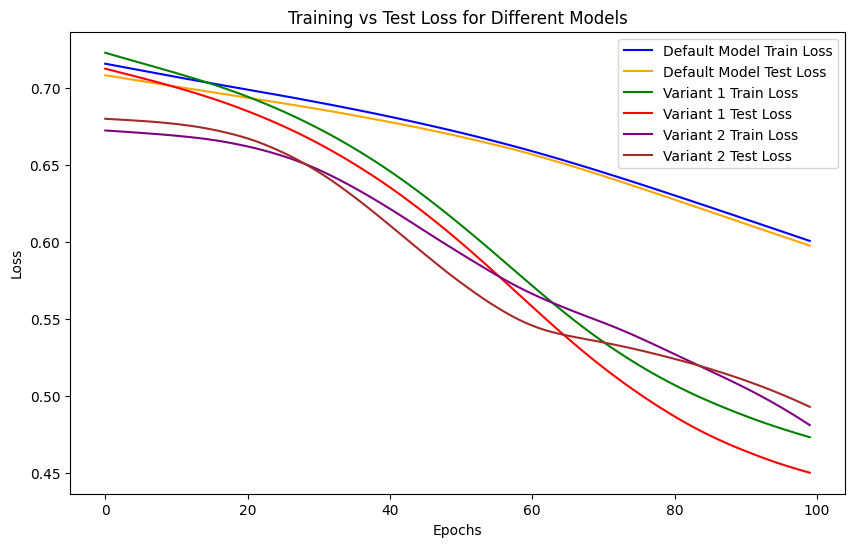

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), losses, label='Default Model Train Loss', color='blue')
plt.plot(range(epochs), test_losses, label='Default Model Test Loss', color='orange')
plt.plot(range(epochs), losses_variant1, label='Variant 1 Train Loss', color='green')
plt.plot(range(epochs), test_losses_variant1, label='Variant 1 Test Loss', color='red')
plt.plot(range(epochs), losses_variant2, label='Variant 2 Train Loss', color='purple')
plt.plot(range(epochs), test_losses_variant2, label='Variant 2 Test Loss', color='brown')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Test Loss for Different Models')
plt.legend()
plt.show()

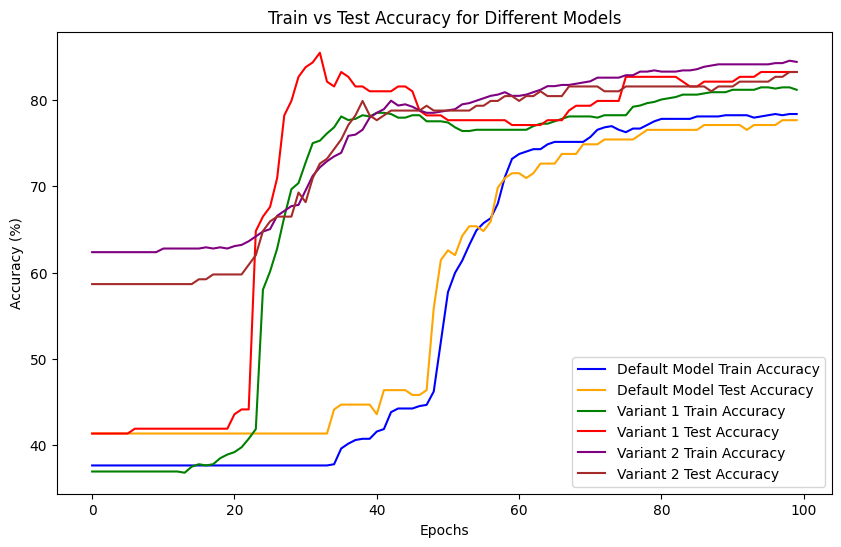

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), train_accuracies, label='Default Model Train Accuracy', color='blue')
plt.plot(range(epochs), test_accuracies, label='Default Model Test Accuracy', color='orange')
plt.plot(range(epochs), train_accuracies_variant1, label='Variant 1 Train Accuracy', color='green')
plt.plot(range(epochs), test_accuracies_variant1, label='Variant 1 Test Accuracy', color='red')
plt.plot(range(epochs), train_accuracies_variant2, label='Variant 2 Train Accuracy', color='purple')
plt.plot(range(epochs), test_accuracies_variant2, label='Variant 2 Test Accuracy', color='brown')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Train vs Test Accuracy for Different Models')
plt.legend()
plt.show()